# IML 2026: Introduction to Machine Learning
## LAB 04 — Linear Regression


### Task 1 — Load and Prepare the Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

housing = fetch_california_housing(as_frame=True)


In [2]:
X = housing.data
y = housing.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nFeature names:")
print(list(X.columns))

print("\nFirst five observations:")
display(X.head())

print("\nFirst five target values:")
display(y.head())


Number of samples: 20640
Number of features: 8

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First five observations:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



First five target values:


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)


Training samples: 16512
Testing samples: 4128
Scaled training shape: (16512, 8)
Scaled testing shape: (4128, 8)


### Task 2 — Linear Regression Model

In [5]:
def predict(X, w, b):
    return X @ w + b


n_features = X_train_scaled.shape[1]

weights = np.zeros(n_features)
bias = 0.0

initial_predictions = predict(X_train_scaled, weights, bias)

print("Initial weights:", weights)
print("Initial bias:", bias)
print("First five initial predictions:", initial_predictions[:5])


Initial weights: [0. 0. 0. 0. 0. 0. 0. 0.]
Initial bias: 0.0
First five initial predictions: [0. 0. 0. 0. 0.]


### Task 3 — Mean Squared Error (Loss Function)

In [6]:

def mse_cost(y_true, y_pred):
    errors = y_true - y_pred
    return np.mean(errors ** 2)


initial_mse = mse_cost(y_train_np, initial_predictions)
print("Initial training MSE:", initial_mse)


Initial training MSE: 5.629742323103131


### Task 4 — Gradient Descent

In [7]:

def train_linear_regression(X, y, learning_rate=0.01, epochs=1000):
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0

    mse_history = []

    for epoch in range(epochs):
        y_pred = predict(X, w, b)
        errors = y - y_pred

        dw = -(2 / n_samples) * (X.T @ errors)
        db = -(2 / n_samples) * np.sum(errors)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        current_predictions = predict(X, w, b)
        current_mse = mse_cost(y, current_predictions)
        mse_history.append(current_mse)

    return w, b, mse_history


learning_rate = 0.01
epochs = 1000

weights, bias, mse_history = train_linear_regression(
    X_train_scaled,
    y_train_np,
    learning_rate=learning_rate,
    epochs=epochs
)

print("Final weights:", weights)
print("Final bias:", bias)
print("Final training MSE:", mse_history[-1])


Final weights: [ 0.8580605   0.1501549  -0.25253771  0.28100715  0.00710958 -0.04344213
 -0.68321834 -0.65415242]
Final bias: 2.0719469338918617
Final training MSE: 0.5245980367816417


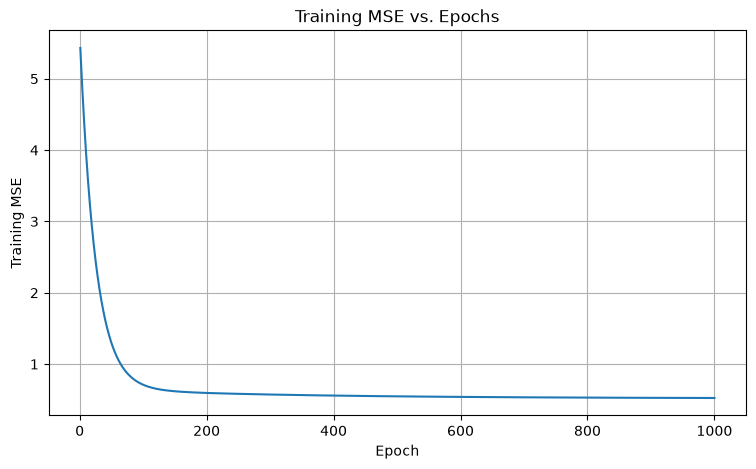

In [8]:

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), mse_history)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training MSE vs. Epochs")
plt.grid(True)
plt.show()

### Task 5 — Prediction and Evaluation

In [9]:

y_test_pred = predict(X_test_scaled, weights, bias)

test_mse = mean_squared_error(y_test_np, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_np, y_test_pred)

print("From-scratch Linear Regression:")
print(f"MSE  : {test_mse:.6f}")
print(f"RMSE : {test_rmse:.6f}")
print(f"R2   : {test_r2:.6f}")


From-scratch Linear Regression:
MSE  : 0.554580
RMSE : 0.744701
R2   : 0.576789


### Task 6 — Visualization

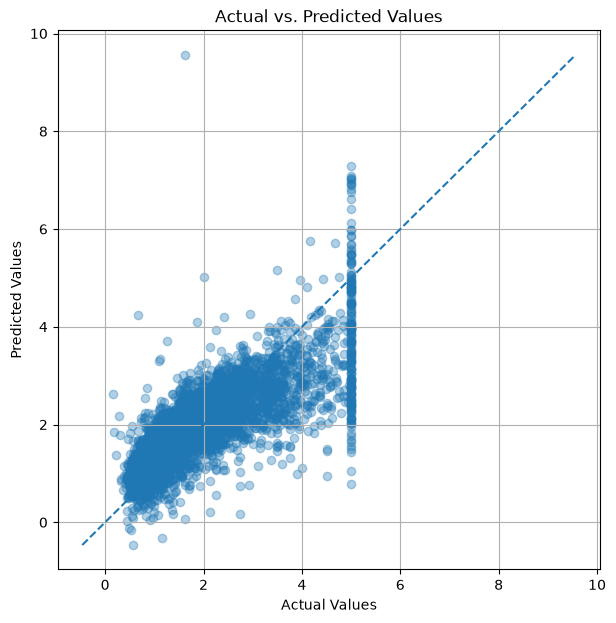

In [10]:

plt.figure(figsize=(7, 7))
plt.scatter(y_test_np, y_test_pred, alpha=0.35)

minimum = min(y_test_np.min(), y_test_pred.min())
maximum = max(y_test_np.max(), y_test_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.grid(True)
plt.show()


### Task 7 — Verification Using a Standard Library Model

In [11]:

from sklearn.linear_model import LinearRegression

library_model = LinearRegression()
library_model.fit(X_train_scaled, y_train_np)

library_predictions = library_model.predict(X_test_scaled)

library_mse = mean_squared_error(y_test_np, library_predictions)
library_rmse = np.sqrt(library_mse)
library_r2 = r2_score(y_test_np, library_predictions)

comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R2"],
    "From Scratch": [test_mse, test_rmse, test_r2],
    "Library Implementation": [library_mse, library_rmse, library_r2]
})

display(comparison)


,Metric,From Scratch,Library Implementation
0,MSE,0.554580,0.555892
1,RMSE,0.744701,0.745581
2,R2,0.576789,0.575788
